In [1]:
import pickle
import matplotlib.pyplot as plt
import scipy.signal as sig
import control
import pandas as pd
import numpy as np

In [2]:
# Прочитаем исходные данные некоторого эксперимента в АДТ
data = pickle.load(open('data.pickle', 'rb'))

Посмотрим, что из себя представляют данные

In [3]:
print(type(data))

<class 'numpy.ndarray'>


In [4]:
df = pd.DataFrame(data)

In [5]:
df.describe()

,time,alpha,beta,gamma,X,Y,Z,Mx,My,Mz,q
count,48000.000000,48000.000000,48000.0,48000.0,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
mean,9.999792,27.489248,0.0,0.0,0.542086,16.331511,0.238412,0.047255,-0.035283,-0.457397,100.997040
std,5.773563,12.444139,0.0,0.0,0.909561,1.477581,0.875764,0.161073,0.208465,0.326097,0.379334
min,0.000000,-34.139310,0.0,0.0,-3.047889,11.072096,-3.031549,-0.579029,-0.659158,-1.526754,99.682489
25%,4.999896,19.243609,0.0,0.0,0.003637,15.232545,-0.358598,-0.057509,-0.182286,-0.691090,100.744446
50%,9.999792,27.631054,0.0,0.0,0.553688,16.399282,0.225316,0.048833,-0.036561,-0.449212,101.010172
75%,14.999687,35.801929,0.0,0.0,1.066790,17.445757,0.831568,0.154176,0.113224,-0.237542,101.222366
max,19.999583,74.523985,0.0,0.0,4.287494,20.786471,3.505057,0.616860,0.606372,0.546760,102.223749


Имеем данные формата `numpy.ndarray` с полями:
* `time` -- время
* `alpha`, `beta`, `gamma` -- углы атаки скольжения и крена
* `X`, `Y`, `Z` -- силы, дествующие на модель
* `Mx`, `My`, `Mz` -- моменты, действующие на модель

Из краткой сводке по данным, можем наблюдать:
* продолжительность эксперимента около 20 секунд
* изменяющимся параметром эксперимента является угол атаки (причём значения этого параметра весьма зашумлены)

Отрисуем некоторые значения записанных параметров.

In [6]:
# Массив времём измерений
time = data['time']

# Три массива с измерениями
alpha = data['alpha']
x = data['X']
y = data['Y']

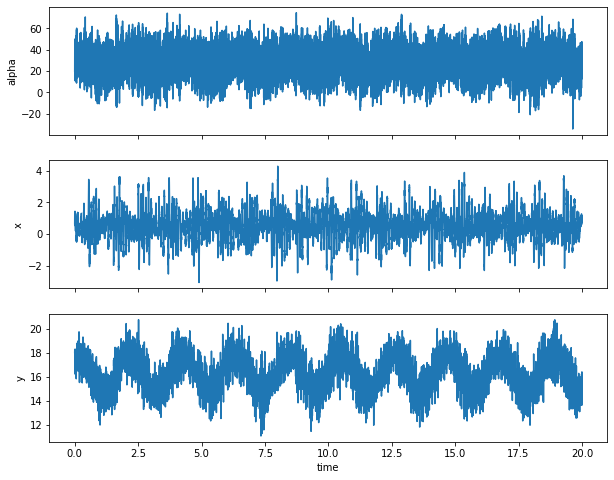

In [7]:
_, (a1, a2, a3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
a1.plot(time, alpha)
a1.set(ylabel='alpha')
a2.plot(time, x)
a2.set(ylabel='x')
a3.plot(time, y)
a3.set(ylabel='y', xlabel='time')
pass

# Задание

1. Глядя на сигнал $y$, поберите значение частоты среза $\omega_0$ для фильтра (апериодического, Баттерворта или Чебышёва).
2. Опытным путём фильтруя $y$, найдите другие параметры выбранного вами фильтра.
3. Примените полученный фильтр к сигналам $x$ и $\alpha$.

In [ ]:
#Фильтр Баттерворта 2ого порядка

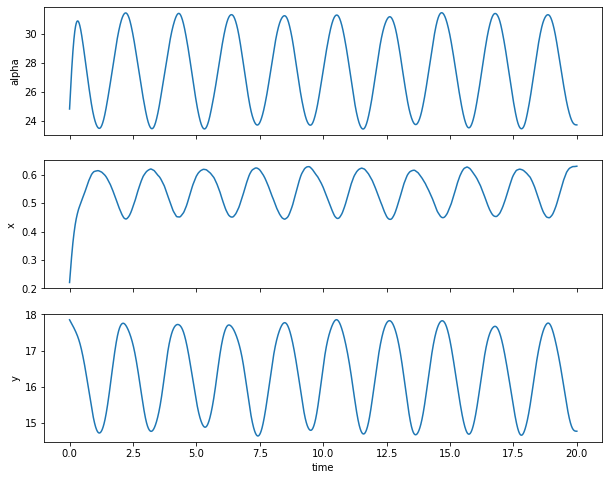

In [8]:
x, y = sig.butter(2, 0.001, 'lowpass')
yfun = sig.filtfilt(x, y, data['Y'])
xfun = sig.filtfilt(x, y, data['X'])
afun = sig.filtfilt(x, y, data['alpha'])

_, (a1, a2, a3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
a1.plot(time, afun)
a1.set(ylabel='alpha')
a2.plot(time, xfun)
a2.set(ylabel='x')
a3.plot(time, yfun)
a3.set(ylabel='y', xlabel='time')
pass